# Mini caso 4 — Buscador documental con TF-IDF

En este notebook se construye un buscador sencillo sobre el corpus documental del 23-F.

La idea es dividir los documentos en fragmentos más pequeños y representar cada fragmento mediante TF-IDF. Después, ante una consulta del usuario, se calcula la similitud coseno entre la consulta y los fragmentos del corpus.

El objetivo es recuperar documentos o fragmentos relacionados con una pregunta, manteniendo siempre la trazabilidad mediante `doc_id`, título y enlace al PDF original.

El proceso será:

- cargar el corpus limpio;
- seleccionar las columnas necesarias;
- dividir los textos largos en fragmentos;
- crear una matriz TF-IDF;
- buscar fragmentos similares a una consulta;
- recomendar documentos relacionados;
- hacer una evaluación sencilla de recuperación.

## 0. Configuración inicial

Se definen algunos parámetros básicos del buscador, como el tamaño de los fragmentos, el número de resultados a mostrar y el número de palabras que se enseñan como evidencia.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)

RANDOM_STATE = 42

CHUNK_MAX_WORDS = 220
CHUNK_OVERLAP = 40
TOP_K = 5
SNIPPET_WORDS = 45

# Stopwords básicas en español para el TF-IDF.
SPANISH_STOPWORDS = [
    "a","al","algo","algunas","algunos","ante","antes","como","con","contra","cual","cuando",
    "de","del","desde","donde","durante","e","el","ella","ellas","ellos","en","entre","era",
    "erais","eran","eras","eres","es","esa","esas","ese","eso","esos","esta","estaba","estaban",
    "estado","estais","estamos","estan","estar","estas","este","esto","estos","estoy","fue",
    "fueron","fui","fuimos","ha","habeis","habia","habian","han","hasta","hay","la","las","le",
    "les","lo","los","mas","me","mi","mis","mucho","muchos","muy","nada","ni","no","nos","nosotros",
    "o","os","otra","otras","otro","otros","para","pero","poco","por","porque","que","quien",
    "quienes","se","sea","sean","segun","ser","si","sido","sin","sobre","sois","somos","son","su",
    "sus","tambien","tanto","te","tenia","tiene","tienen","todo","todos","tu","tus","un","una",
    "unas","uno","unos","vosotros","y","ya","yo","mientras","cada","tras",
]

print("Configuración cargada.")
print(f"chunk_max_words={CHUNK_MAX_WORDS} | overlap={CHUNK_OVERLAP} | top_k={TOP_K}")

Configuración cargada.
chunk_max_words=220 | overlap=40 | top_k=5


## 1. Carga de datos

Se utiliza como base el archivo limpio generado en la fase de limpieza general:

`data/processed/rtve_corpus_clean_base.csv`

Este archivo contiene el texto limpio (`text_clean_base`), metadatos básicos, información institucional y enlaces de trazabilidad.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "rtve_corpus_clean_base.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset cargado: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Shape: {df.shape}")
df.head()

Dataset cargado: data/processed/rtve_corpus_clean_base.csv
Shape: (167, 25)


,doc_id,source_document_id,title,pages,detail_url,pdf_url,summary,keywords,text_full,text_clean_base,text_length_chars,text_length_words,text_clean_length_chars,text_clean_length_words,moncloa_id,moncloa_section,moncloa_subsection,final_match_status,coverage_moncloa,alpha_ratio,digit_ratio,uppercase_ratio,weird_char_ratio,n_title_years,title_main_year
0,rtve_1860,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,3,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/99_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_20_de_febrer...,"El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, con declaraciones pa...",C/SG/2820/20-02-82 DTOR. Vista oral 2/81,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82\n\n-...,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82\n\n-...,3934,640,3934,640,moncloa_0099,defensa,cni,high_confidence_match,True,0.777834,0.013726,0.147386,0.000000,1,1982.0
1,rtve_1859,1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,4,https://23fbuscador.rtve.es/document/ocr/1859?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/98_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_22_de_febrer...,Resumen global del documento:\n\nEl documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febrero de 1982 por el C...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Supremo de Justicia Militar,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.- DESARROLLO DE LA SE...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.- DESARROLLO DE LA SE...,6417,1018,6417,1018,moncloa_0098,defensa,cni,high_confidence_match,True,0.781985,0.009506,0.195895,0.000156,1,1982.0
2,rtve_1858,1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,5,https://23fbuscador.rtve.es/document/ocr/1858?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/97_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_24_de_febrer...,Resumen global del documento:\n\nEl documento narra el desarrollo tenso y conflictivo de una serie de sesiones del Consejo Supremo de Ju...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Supremo de Justicia Militar,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## 1.- DESARROLLO DE LA...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## 1.- DESARROLLO DE LA...,8183,1347,8183,1347,moncloa_0097,defensa,cni,high_confidence_match,True,0.784920,0.011487,0.124085,0.000611,1,1982.0
3,rtve_1857,1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,6,https://23fbuscador.rtve.es/document/ocr/1857?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/96_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_25_de_febrer...,El documento recoge el desarrollo de la sesión del Consejo Supremo de Justicia Militar en febrero de 1982 relativa al juicio por los suc...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Supremo de Justicia Militar,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## 1.- DESARROLLO DE LA...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## 1.- DESARROLLO DE LA...,11151,1826,11151,1826,moncloa_0096,defensa,cni,high_confidence_match,True,0.789257,0.008250,0.128167,0.000538,1,1982.0
4,rtve_1856,1

## 2. Selección de campos útiles

Para construir el buscador no se necesitan todas las columnas del dataset. Los campos mínimos son:

- `doc_id`: identificador trazable del documento;
- `title`: título del documento;
- `text_clean_base`: texto limpio que servirá como base de búsqueda;
- `pdf_url`: enlace al documento original;
- `moncloa_section`: sección institucional, si está disponible;
- `text_clean_length_words`: longitud del texto limpio.

Estos campos permiten recuperar evidencia y mostrar al usuario de dónde procede cada resultado.

In [3]:
required_columns = [
    "doc_id",
    "title",
    "text_clean_base",
    "pdf_url",
    "moncloa_section",
    "text_clean_length_words",
]

missing_columns = [c for c in required_columns if c not in df.columns]
print("Columnas requeridas ausentes:", missing_columns)

# Si faltase la longitud, se recalcula a partir del texto limpio (robustez).
if "text_clean_length_words" in missing_columns and "text_clean_base" in df.columns:
    df["text_clean_length_words"] = df["text_clean_base"].fillna("").str.split().str.len()
    missing_columns = [c for c in required_columns if c not in df.columns]

df_assistant = df[required_columns].copy()
df_assistant["text_clean_base"] = df_assistant["text_clean_base"].fillna("").astype(str)
df_assistant.head()

Columnas requeridas ausentes: []


,doc_id,title,text_clean_base,pdf_url,moncloa_section,text_clean_length_words
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82\n\n-...,https://www.rtve.es/contenidos/documentos/23f-desclasificado/99_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_20_de_febrer...,defensa,640
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.- DESARROLLO DE LA SE...,https://www.rtve.es/contenidos/documentos/23f-desclasificado/98_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_22_de_febrer...,defensa,1018
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## 1.- DESARROLLO DE LA...,https://www.rtve.es/contenidos/documentos/23f-desclasificado/97_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_24_de_febrer...,defensa,1347
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## 1.- DESARROLLO DE LA...,https://www.rtve.es/contenidos/documentos/23f-desclasificado/96_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_25_de_febrer...,defensa,1826
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).,"C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral de la causa 2/81, del Consejo Supremo de Justicia Militar.\n\n## 1.-...",https://www.rtve.es/contenidos/documentos/23f-desclasificado/95_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_26_de_febrer...,defensa,1740


## 3. Validación de textos disponibles

Antes de construir el índice de búsqueda se comprueba que todos los documentos tienen texto limpio disponible. El sistema solo es viable si existe suficiente contenido textual para recuperar evidencias relevantes.

In [4]:
text_availability = {
    "n_documents": len(df_assistant),
    "n_text_available": int(df_assistant["text_clean_base"].str.strip().ne("").sum()),
    "n_empty_text": int((df_assistant["text_clean_base"].str.strip() == "").sum()),
    "min_text_length_words": int(df_assistant["text_clean_length_words"].min()),
    "median_text_length_words": float(df_assistant["text_clean_length_words"].median()),
    "mean_text_length_words": round(float(df_assistant["text_clean_length_words"].mean()), 1),
    "max_text_length_words": int(df_assistant["text_clean_length_words"].max()),
}
pd.DataFrame(text_availability.items(), columns=["check", "value"])

,check,value
0,n_documents,167.0
1,n_text_available,167.0
2,n_empty_text,0.0
3,min_text_length_words,72.0
4,median_text_length_words,579.0
5,mean_text_length_words,2075.4
6,max_text_length_words,95293.0


## 4. Revisión de longitudes y necesidad de fragmentación

El buscador puede trabajar a nivel de documento completo o a nivel de fragmento. El EDA general mostró que el corpus es muy heterogéneo: conviven documentos breves con documentos muy extensos. Para preguntas concretas, trabajar con documentos completos puede ser poco preciso, porque un texto largo mezcla muchos temas. Se revisa cuántos documentos superan umbrales razonables de longitud.

In [5]:
length_thresholds = [1000, 3000, 5000, 10000]
length_review = []
for threshold in length_thresholds:
    n_docs = int((df_assistant["text_clean_length_words"] > threshold).sum())
    length_review.append({
        "threshold_words": threshold,
        "n_documents_above_threshold": n_docs,
        "percentage": round(n_docs / len(df_assistant) * 100, 2),
    })
pd.DataFrame(length_review)

,threshold_words,n_documents_above_threshold,percentage
0,1000,63,37.72
1,3000,18,10.78
2,5000,9,5.39
3,10000,6,3.59


In [6]:
(df_assistant
    .sort_values("text_clean_length_words", ascending=False)
    .head(10)[["doc_id", "title", "moncloa_section", "text_clean_length_words", "pdf_url"]])

,doc_id,title,moncloa_section,text_clean_length_words,pdf_url
161,rtve_1699,Transcripción de cintas grabadas con conversaciones telefónicas con varias personas intervenidas a la esposa de Tejero.,interior,95293,https://www.rtve.es/contenidos/documentos/23f-desclasificado/07_2026_transcripcion_de_cintas_grabadas_con_conversaciones_telefonicas_con...
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª sección EM el día 23-F informando del estado de situación (23 de febrero de 1981).,interior,19857,https://www.rtve.es/contenidos/documentos/23f-desclasificado/09_1981_telex_interiores_y_de_agencias_recibidos_en_2%C2%AA_seccion_em_el_d...
63,rtve_1797,Investigación y declaraciones personal AOME por JDDI (9 de abril de 1981).,defensa,14485,https://www.rtve.es/contenidos/documentos/23f-desclasificado/36_1981_investigacion_y_declaraciones_personal_aome_por_jddi_9_de_abril_de_...
76,rtve_1784,Policía Nacional. Informe de situación. Marca: reservado-confidencial (12 de noviembre de 1981).,interior,13639,https://www.rtve.es/contenidos/documentos/23f-desclasificado/23_1981_policia_nacional_informe_de_situacion_marca_reservado_confidencial_...
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo del juicio",interior,11080,https://www.rtve.es/contenidos/documentos/23f-desclasificado/25_2026_juicio_del_23_f_acotaciones_al_desarrollo_del_juicio_notas_procesal...
126,rtve_1734,"""Nota Informativa sobre la repercusión en prensa del arresto de Tejero en 1978 cuando era Jefe de la Comandancia de Málaga",interior,10253,https://www.rtve.es/contenidos/documentos/23f-desclasificado/12_1978_nota_informativa_sobre_la_repercusion_en_prensa_del_arresto_de_teje...
50,rtve_1810,Relato de los sucesos de los días 23 y 24 de febrero.,defensa,8965,https://www.rtve.es/contenidos/documentos/23f-desclasificado/49_2026_relato_de_los_sucesos_de_los_dias_23_y_24_de_febrero.pdf
157,rtve_1703,Semestral de la amenaza interior (10 de febrero de 1981; 9 de marzo de 1981).,defensa,8714,https://www.rtve.es/contenidos/documentos/23f-desclasificado/101_1981_semestral_de_la_amenaza_interior_10_de_febrero_de_1981_9_de_marzo_...
93,rtve_1767,"""Informe de las distintas Jefaturas Superiores: Comisaría General de Información. """"Situación actual en las distintas regiones policiale...",interior,7189,https://www.rtve.es/contenidos/documentos/23f-desclasificado/15_1981_informe_de_las_distintas_jefaturas_superiores_comisaria_general_de_...
163,rtve_1697,"""Documentación con una presunta planificación del golpe",interior,4882,https://www.rtve.es/contenidos/documentos/23f-desclasificado/05_1980_documentacion_con_una_presunta_planificacion_del_golpe_manuscrita_1...


**Lectura del bloque.** La revisión confirma que la fragmentación es necesaria para una parte del corpus: una búsqueda a nivel de documento completo recuperaría el documento correcto, pero no necesariamente el pasaje que responde a la pregunta. Por ello, el sistema indexa **fragmentos** (`chunks`) manteniendo la trazabilidad al documento de origen mediante `doc_id`, título y enlace al PDF.

## 5. Fragmentación del corpus en *chunks*

Se divide cada documento en fragmentos solapados de longitud acotada (`CHUNK_MAX_WORDS`), con un solape (`CHUNK_OVERLAP`) que evita cortar ideas justo en el límite entre fragmentos.

- Los documentos cortos (≤ `CHUNK_MAX_WORDS`) generan un único fragmento.
- Los documentos largos se reparten en varios fragmentos numerados.
- Cada fragmento conserva su `doc_id`, título y enlace al PDF, de modo que cualquier resultado de búsqueda puede rastrearse hasta el documento original.

In [7]:
def chunk_document(text, max_words=CHUNK_MAX_WORDS, overlap=CHUNK_OVERLAP):
    """Divide un texto en fragmentos solapados a nivel de palabra."""
    words = text.split()
    if len(words) <= max_words:
        return [{"chunk_index": 0, "n_words": len(words), "text": " ".join(words)}]
    chunks, step, start, idx = [], max_words - overlap, 0, 0
    while start < len(words):
        piece = words[start:start + max_words]
        if not piece:
            break
        chunks.append({"chunk_index": idx, "n_words": len(piece), "text": " ".join(piece)})
        idx += 1
        start += step
    return chunks


records = []
for _, row in df_assistant.iterrows():
    for ch in chunk_document(row["text_clean_base"]):
        records.append({
            "chunk_id": f"{row['doc_id']}::c{ch['chunk_index']:03d}",
            "doc_id": row["doc_id"],
            "title": row["title"],
            "pdf_url": row["pdf_url"],
            "moncloa_section": row["moncloa_section"],
            "chunk_index": ch["chunk_index"],
            "n_words": ch["n_words"],
            "text": ch["text"],
        })

df_chunks = pd.DataFrame(records).reset_index(drop=True)

print(f"Documentos: {df_assistant['doc_id'].nunique()}")
print(f"Fragmentos totales: {len(df_chunks)}")
print(f"Media de fragmentos por documento: {len(df_chunks)/df_assistant['doc_id'].nunique():.2f}")
print(f"Máx. fragmentos en un documento: {df_chunks['doc_id'].value_counts().max()}")
df_chunks["n_words"].describe().round(1)

Documentos: 167
Fragmentos totales: 1998
Media de fragmentos por documento: 11.96
Máx. fragmentos en un documento: 530


count    1998.0
mean      209.9
std        35.7
min         2.0
25%       220.0
50%       220.0
75%       220.0
max       220.0
Name: n_words, dtype: float64

In [8]:
# Distribución de fragmentos por documento (top-10 documentos más fragmentados)
(df_chunks["doc_id"].value_counts()
    .head(10)
    .rename_axis("doc_id")
    .reset_index(name="n_chunks"))

,doc_id,n_chunks
0,rtve_1699,530
1,rtve_1701,111
2,rtve_1797,81
3,rtve_1784,76
4,rtve_1786,62
5,rtve_1734,57
6,rtve_1810,50
7,rtve_1703,49
8,rtve_1767,40
9,rtve_1697,28


## 6. Representación vectorial — baseline TF-IDF

El baseline representa cada fragmento mediante **TF-IDF** con unigramas y bigramas. Es interpretable, rápido y no requiere modelos externos. El vectorizador aplica:

- *stopwords* en español y minúsculas;
- unigramas y bigramas (`ngram_range=(1, 2)`) para captar expresiones como *guardia civil* o *coronel tejero*;
- `min_df=2` para descartar ruido OCR muy infrecuente;
- normalización L2 (por defecto), de modo que el producto escalar equivale a la **similitud coseno**.

In [9]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=SPANISH_STOPWORDS,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
)

tfidf_chunk_matrix = tfidf_vectorizer.fit_transform(df_chunks["text"])

print(f"Matriz TF-IDF de fragmentos: {tfidf_chunk_matrix.shape}")
print(f"Tamaño del vocabulario: {len(tfidf_vectorizer.vocabulary_)}")

Matriz TF-IDF de fragmentos: (1998, 52850)
Tamaño del vocabulario: 52850


## 7. Motor de búsqueda con similitud coseno

Una vez creada la matriz TF-IDF, se define una función sencilla para buscar los fragmentos más parecidos a una consulta.

La consulta se transforma con el mismo vectorizador TF-IDF y después se calcula la similitud coseno frente a todos los fragmentos del corpus.

In [10]:
def crear_snippet(texto, n_words=SNIPPET_WORDS):
    palabras = str(texto).split()
    snippet = " ".join(palabras[:n_words])
    if len(palabras) > n_words:
        snippet += " ..."
    return snippet


def buscar(query, k=TOP_K, nivel="documento", seccion=None):
    query_vector = tfidf_vectorizer.transform([query])
    scores = cosine_similarity(query_vector, tfidf_chunk_matrix).ravel()

    results = df_chunks[
        [
            "chunk_id",
            "doc_id",
            "title",
            "moncloa_section",
            "chunk_index",
            "pdf_url",
            "text",
        ]
    ].copy()

    results["score"] = scores

    if seccion is not None:
        results = results[results["moncloa_section"] == seccion]

    results = results.sort_values("score", ascending=False)

    if nivel == "documento":
        results = results.drop_duplicates("doc_id")

    results = results.head(k).reset_index(drop=True)
    results["evidencia"] = results["text"].apply(crear_snippet)
    results["score"] = results["score"].round(4)

    return results[
        [
            "score",
            "doc_id",
            "title",
            "moncloa_section",
            "chunk_index",
            "evidencia",
            "pdf_url",
        ]
    ]


def mostrar_resultados(query, k=TOP_K, nivel="documento", seccion=None):
    print(f"Consulta: {query}")
    print("=" * 100)

    resultados = buscar(
        query=query,
        k=k,
        nivel=nivel,
        seccion=seccion
    )

    for i, row in resultados.iterrows():
        print(f"[{i+1}] score={row['score']} | doc_id={row['doc_id']} | sección={row['moncloa_section']}")
        print(f"Título: {row['title']}")
        print(f"Evidencia: {row['evidencia']}")
        print(f"PDF: {row['pdf_url']}")
        print("-" * 100)

    return resultados

## 8. Búsqueda por pregunta del usuario

Se definen consultas de ejemplo coherentes con el dominio del 23-F y se ejecuta el buscador. Cada respuesta muestra los documentos más relevantes con su evidencia y enlace al PDF.

In [11]:
example_queries = [
    "¿Qué documentos mencionan al CESID?",
    "¿Qué aparece sobre Tejero en las vistas orales?",
    "¿Qué documentos hablan de la Guardia Civil?",
    "¿Qué documentos tratan sobre la sentencia?",
    "¿Qué actores institucionales aparecen en documentos de Defensa?",
]
pd.DataFrame({"example_query": example_queries})

,example_query
0,¿Qué documentos mencionan al CESID?
1,¿Qué aparece sobre Tejero en las vistas orales?
2,¿Qué documentos hablan de la Guardia Civil?
3,¿Qué documentos tratan sobre la sentencia?
4,¿Qué actores institucionales aparecen en documentos de Defensa?


In [12]:
# Demostración con una consulta de ejemplo
_ = mostrar_resultados(example_queries[1], k=5, nivel="documento")

Consulta: ¿Qué aparece sobre Tejero en las vistas orales?
[1] score=0.0856 | doc_id=rtve_1699 | sección=interior
Título: Transcripción de cintas grabadas con conversaciones telefónicas con varias personas intervenidas a la esposa de Tejero.
Evidencia: --- FIN DE LA CARA 1 DE ESTA CINTA CONVERSACIONES DE LA ESPOSA DEL TTE. CORONEL TEJERO CON OTRAS PERSONAS (2a parte de la cinta) A - Diga? B - ¿Carmen? A - ¿Quien es? B - Herminio. A - Herminio ¿ha visto hijo ... ...
PDF: https://www.rtve.es/contenidos/documentos/23f-desclasificado/07_2026_transcripcion_de_cintas_grabadas_con_conversaciones_telefonicas_con_varias_perso.pdf
----------------------------------------------------------------------------------------------------
[2] score=0.0713 | doc_id=rtve_1784 | sección=interior
Título: Policía Nacional. Informe de situación. Marca: reservado-confidencial (12 de noviembre de 1981).
Evidencia: CEHE, Carlos Pérez. Prepudiado si apoyan al presidente Calvo-Serdo, Morillo respondió: «Claro que lo

In [13]:
# Tabla resumen: top-3 documentos para cada consulta de ejemplo
filas = []

for q in example_queries:
    top = buscar(q, k=3, nivel="documento")

    for rank, row in top.iterrows():
        filas.append({
            "consulta": q,
            "rank": rank + 1,
            "score": row["score"],
            "doc_id": row["doc_id"],
            "seccion": row["moncloa_section"],
            "title": row["title"][:70],
        })

search_examples = pd.DataFrame(filas)
search_examples

,consulta,rank,score,doc_id,seccion,title
0,¿Qué documentos mencionan al CESID?,1,0.1243,rtve_1860,defensa,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero
1,¿Qué documentos mencionan al CESID?,2,0.1007,rtve_1743,exteriores,D.1._AGMAE_R39017_Exp._4
2,¿Qué documentos mencionan al CESID?,3,0.0919,rtve_1698,interior,Documento manuscrito de posible planificación del golpe.
3,¿Qué aparece sobre Tejero en las vistas orales?,1,0.0856,rtve_1699,interior,Transcripción de cintas grabadas con conversaciones telefónicas con va
4,¿Qué aparece sobre Tejero en las vistas orales?,2,0.0713,rtve_1784,interior,Policía Nacional. Informe de situación. Marca: reservado-confidencial
5,¿Qué aparece sobre Tejero en las vistas orales?,3,0.0706,rtve_1767,interior,"""Informe de las distintas Jefaturas Superiores: Comisaría General de I"
6,¿Qué documentos hablan de la Guardia Civil?,1,0.0807,rtve_1743,exteriores,D.1._AGMAE_R39017_Exp._4
7,¿Qué documentos hablan de la Guardia Civil?,2,0.0736,rtve_1698,interior,Documento manuscrito de posible planificación del golpe.
8,¿Qué documentos hablan de la Guardia Civil?,3,0.0681,rtve_1696,interior,Conversaciones telefónicas de (presuntamente) la unidad militar El Par
9,¿Qué documentos tratan sobre la sentencia?,1,0.0970,rtve_1743,exteriores,D.1._AGMAE_R39017_Exp._4


## 9. Recomendación de documentos relacionados

Además de buscar por consulta, se puede recomendar documentos parecidos a uno dado.

Para ello se representa cada documento completo con el mismo vectorizador TF-IDF y se calcula la similitud coseno entre documentos.

In [14]:
doc_ids = df_assistant["doc_id"].tolist()
doc_index = {doc_id: i for i, doc_id in enumerate(doc_ids)}

doc_tfidf_matrix = tfidf_vectorizer.transform(df_assistant["text_clean_base"])

meta = df_assistant.set_index("doc_id")


def recomendar_documentos(doc_id, k=TOP_K):
    if doc_id not in doc_index:
        raise KeyError(f"doc_id desconocido: {doc_id}")

    i = doc_index[doc_id]
    scores = cosine_similarity(doc_tfidf_matrix[i], doc_tfidf_matrix).ravel()

    order = np.argsort(-scores)
    order = [j for j in order if j != i][:k]

    recomendaciones = pd.DataFrame({
        "score": np.round(scores[order], 4),
        "doc_id": [doc_ids[j] for j in order],
        "title": [meta.loc[doc_ids[j], "title"] for j in order],
        "moncloa_section": [meta.loc[doc_ids[j], "moncloa_section"] for j in order],
        "pdf_url": [meta.loc[doc_ids[j], "pdf_url"] for j in order],
    })

    return recomendaciones


ejemplo_doc = doc_ids[0]

print(f"Documento de referencia: {ejemplo_doc}")
print(meta.loc[ejemplo_doc, "title"])

recomendar_documentos(ejemplo_doc, k=5)

Documento de referencia: rtve_1860
Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).


,score,doc_id,title,moncloa_section,pdf_url
0,0.1796,rtve_1702,Vista oral 2/81 del Consejo Supremo de Justicia Militar (19 de febrero de 1982).,defensa,https://www.rtve.es/contenidos/documentos/23f-desclasificado/100_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_19_de_febre...
1,0.1754,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,defensa,https://www.rtve.es/contenidos/documentos/23f-desclasificado/98_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_22_de_febrer...
2,0.1506,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,defensa,https://www.rtve.es/contenidos/documentos/23f-desclasificado/96_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_25_de_febrer...
3,0.1491,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,defensa,https://www.rtve.es/contenidos/documentos/23f-desclasificado/97_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_24_de_febrer...
4,0.1421,rtve_1810,Relato de los sucesos de los días 23 y 24 de febrero.,defensa,https://www.rtve.es/contenidos/documentos/23f-desclasificado/49_2026_relato_de_los_sucesos_de_los_dias_23_y_24_de_febrero.pdf


## 10. Evaluación sencilla del buscador

Como no tenemos un conjunto real de preguntas etiquetadas, se hace una prueba sencilla.

Se toma una muestra de documentos y, para cada uno, se extrae un pequeño fragmento del propio texto como consulta. Después se comprueba si el buscador recupera el documento original entre los primeros resultados.

Esta prueba no mide la utilidad real para un usuario, pero sirve para comprobar si el índice TF-IDF recupera documentos relacionados con el texto de entrada.

In [15]:
def evaluar_known_item(n_muestra=60, k_max=5, snippet_words=25, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)

    candidatos = df_assistant[
        df_assistant["text_clean_length_words"] >= 60
    ]["doc_id"].tolist()

    n_muestra = min(n_muestra, len(candidatos))
    muestra = rng.choice(candidatos, size=n_muestra, replace=False)

    recall_at = {1: 0, 3: 0, 5: 0}
    reciprocal_ranks = []

    for doc_id in muestra:
        words = meta.loc[doc_id, "text_clean_base"].split()
        mid = max(0, len(words) // 2 - snippet_words // 2)
        pseudo_query = " ".join(words[mid:mid + snippet_words])

        top = buscar(pseudo_query, k=k_max, nivel="documento")
        ids = top["doc_id"].tolist()

        rank = ids.index(doc_id) + 1 if doc_id in ids else None

        for kk in recall_at:
            if rank is not None and rank <= kk:
                recall_at[kk] += 1

        reciprocal_ranks.append(1.0 / rank if rank else 0.0)

    return {
        "n_consultas": int(n_muestra),
        "recall@1": round(recall_at[1] / n_muestra, 3),
        "recall@3": round(recall_at[3] / n_muestra, 3),
        "recall@5": round(recall_at[5] / n_muestra, 3),
        "MRR@5": round(float(np.mean(reciprocal_ranks)), 3),
    }


df_eval = pd.DataFrame([
    evaluar_known_item(n_muestra=60)
])

df_eval

,n_consultas,recall@1,recall@3,recall@5,MRR@5
0,60,1.0,1.0,1.0,1.0


**Lectura del output.**  
La evaluación devuelve valores perfectos de `recall@1`, `recall@3`, `recall@5` y `MRR@5`. Esto indica que el índice TF-IDF recupera correctamente el documento de origen cuando la consulta se construye a partir de un fragmento del propio documento.

Aun así, este resultado debe interpretarse con cautela. Es una prueba sencilla y favorable al modelo, porque la consulta comparte vocabulario directo con el documento que se intenta recuperar. Por tanto, no demuestra que el buscador vaya a responder siempre bien a preguntas reales formuladas por usuarios.

La utilidad principal de esta evaluación es comprobar que el índice funciona y que la recuperación documental es coherente.

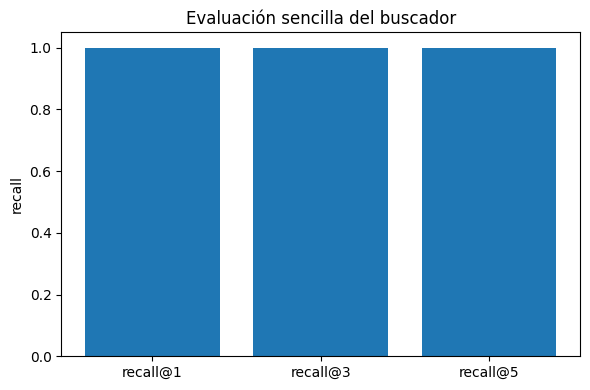

Figura guardada en: outputs/figures/caso4_recall_at_k.png


In [16]:
import matplotlib.pyplot as plt

fig_dir = PROJECT_ROOT / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

ks = ["recall@1", "recall@3", "recall@5"]
values = [df_eval.loc[0, k] for k in ks]

plt.figure(figsize=(6, 4))
plt.bar(ks, values)
plt.ylim(0, 1.05)
plt.ylabel("recall")
plt.title("Evaluación sencilla del buscador")
plt.tight_layout()

fig_path = fig_dir / "caso4_recall_at_k.png"
plt.savefig(fig_path, dpi=120)
plt.show()

print(f"Figura guardada en: {fig_path.relative_to(PROJECT_ROOT)}")

## 11. Guardado de resultados

Se guardan dos resultados útiles para el informe:

- la tabla de fragmentos generados;
- algunos ejemplos de búsquedas realizadas con TF-IDF.

In [17]:
(PROJECT_ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "outputs" / "tables").mkdir(parents=True, exist_ok=True)

chunks_path = PROJECT_ROOT / "data" / "processed" / "rtve_corpus_chunks.csv"
df_chunks.to_csv(chunks_path, index=False)

ejemplos_path = PROJECT_ROOT / "outputs" / "tables" / "caso4_busqueda_ejemplos.csv"
search_examples.to_csv(ejemplos_path, index=False)

for path in [chunks_path, ejemplos_path]:
    print("Guardado:", path.relative_to(PROJECT_ROOT))

Guardado: data/processed/rtve_corpus_chunks.csv
Guardado: outputs/tables/caso4_busqueda_ejemplos.csv


## 12. Riesgos y limitaciones

El buscador funciona a partir de similitud textual, por lo que tiene algunas limitaciones.

En primer lugar, depende de la calidad del OCR y del texto limpio. Si un documento tiene mucho ruido, la representación TF-IDF también puede verse afectada.

En segundo lugar, TF-IDF detecta coincidencias de vocabulario, pero no entiende el significado profundo de una pregunta. Por eso puede fallar si el usuario usa palabras muy diferentes a las que aparecen en el documento.

Además, la evaluación usada es una prueba sencilla de recuperación del documento original. Sirve para comprobar que el índice funciona, pero no sustituye una evaluación real con preguntas formuladas por usuarios.

Aun así, cada resultado mantiene trazabilidad mediante `doc_id`, título, fragmento de evidencia y enlace al PDF original.

## 13. Conclusiones

En este mini caso se ha construido un buscador documental sencillo sobre el corpus del 23-F.

El sistema divide los documentos en fragmentos y los representa mediante TF-IDF. A partir de una consulta, calcula la similitud coseno y devuelve los fragmentos o documentos más cercanos.

El resultado es útil porque cada búsqueda mantiene la trazabilidad: se muestra el `doc_id`, el título, un fragmento de evidencia y el enlace al PDF original.

La evaluación sencilla indica si el buscador es capaz de recuperar el documento de origen cuando se usa un fragmento del propio documento como consulta. Esto no demuestra que el sistema responda perfectamente a preguntas reales, pero sí valida que el índice recupera información relacionada.

Como limitación principal, el enfoque depende mucho de las palabras utilizadas en la consulta. Un modelo con embeddings podría captar mejor relaciones semánticas entre términos distintos, pero se ha dejado como mejora futura para mantener esta primera versión más simple, reproducible y cercana a los métodos de representación textual vistos en clase. Por tanto, TF-IDF funciona aquí como baseline interpretable sobre el que podrían compararse enfoques más avanzados.